# Readout error mitigation with TREX

Readout (measurement-assignment) error is a **classical bitstring flip** at measurement time:
with a left-stochastic confusion matrix $A$ ($A_{ij}=P(\text{measure } i\mid\text{true } j)$), an
ideal outcome distribution $p$ is reported as $\tilde p = A\,p$. Crucially, **neither ZNE nor PEC
removes it** — those mitigate *gate* noise — so readout sets an error floor that needs its own tool.

**TREX** (Twirled Readout Error eXtinction, van den Berg *et al.*, Nat. Phys. 2022) is *model-free*:
it needs neither $A$ nor its inverse. Before each measurement it applies a random $X^{\mathbf{s}}$ and
classically undoes it ($y = x \oplus \mathbf{s}$). Averaged over $\mathbf{s}$ this **twirls** the
channel into $A^\star=\tfrac{1}{2^n}\sum_{\mathbf{s}} X^{\mathbf{s}} A\, X^{\mathbf{s}}$, which

- **symmetrizes** each qubit's flip rates to $\bar p_i=(p^0_i+p^1_i)/2$ (so an *asymmetric* $A$
  becomes a symmetric $A^\star$), and
- **diagonalizes** the action on Pauli-$Z$ strings:
  $\langle Z_w\rangle_{\text{meas}} = \lambda_w\,\langle Z_w\rangle_{\text{true}}$ with eigenvalue
  $\lambda_w=\prod_{i\in w}(1-p^0_i-p^1_i)$.

Calibration circuits ($|0\dots0\rangle$ + the *same* twirl) estimate $\lambda_w$, and the true value
is recovered by $\langle Z_w\rangle_{\text{true}}=\langle Z_w\rangle_{\text{meas}}/\lambda_w$.

We keep the benchmark quantity $P(\text{target})=\langle|t\rangle\langle t|\rangle$, decomposed into
$Z$-strings so TREX corrects each eigenvalue. Every claim below is validated step-by-step by the
companion scripts `smoke_readout_confusion.py`, `smoke_readout_twirl.py`, `smoke_trex_lambda.py`,
`smoke_trex_end2end.py`. Built on the `qem/` package, mirroring
[DZNE_VS_PEC_mitiq.ipynb](DZNE_VS_PEC_mitiq.ipynb).

## 1. Setup

In [14]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# All project machinery lives in the qem/ package. Make it importable regardless of the
# kernel working directory:
import sys
from pathlib import Path
for _cand in (Path.cwd(), Path.cwd() / "notebooks", *Path.cwd().parents):
    if (_cand / "qem" / "__init__.py").exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break
from qem import *  # ReadoutSpec, READOUT_SYM/ASYM, trex_success_prob, benchmark_circuit_cirq, ...

warnings.filterwarnings("ignore")  # experimental-namespace / near-zero-calib chatter
print("qem loaded. Readout specs:", READOUT_SYM.name, "|", READOUT_ASYM.name, "| IDEAL =", IDEAL)

qem loaded. Readout specs: ReadoutSym | ReadoutAsym | IDEAL = 1.0


## 2. The readout error model and its confusion matrix

`qem/readout.py` adds independent per-qubit bit-flip readout error via Aer's `add_readout_error`,
parameterised by $(p^0_i, p^1_i)=(P(1\mid0),\,P(0\mid1))$ per qubit. Two ready-made 2-qubit specs:
a **symmetric** one ($p^0=p^1$) and an **asymmetric** one ($p^1>p^0$, as on real hardware, where
$1\!\to\!0$ relaxation dominates). We check the analytic confusion matrix $A$ against Aer and list
the twirled eigenvalues $\lambda_w$. *(Validated in `smoke_readout_confusion.py`.)*

In [15]:
def empirical_confusion(spec, shots=200_000):
    """A_emp[measured, true]: prepare each basis state, measure on the readout-noisy backend."""
    n = spec.n_qubits
    be = AerSimulator(noise_model=spec.readout_noise_model())
    A = np.zeros((2**n, 2**n))
    for true in range(2**n):
        qc = QuantumCircuit(n, n)
        for i in range(n):
            if (true >> i) & 1:
                qc.x(i)
        qc.measure(range(n), range(n))
        for k, c in be.run(qc, shots=shots).result().get_counts().items():
            A[int(k, 2), true] = c / shots  # int(k,2): qubit 0 = LSB (little-endian)
    return A

for spec in (READOUT_SYM, READOUT_ASYM):
    A = spec.confusion_matrix()
    lam = {w: round(spec.lambda_support(w), 4) for w in [(0,), (1,), (0, 1)]}
    print(f"{spec.name}:  p0={spec.p0}  p1={spec.p1}")
    print("  A (analytic) =")
    print(np.array2string(A, precision=4, prefix="    "))
    print(f"  max|A - A_empirical| = {np.max(np.abs(A - empirical_confusion(spec))):.2e}  (shot noise)")
    print(f"  twirled eigenvalues  lambda_w = 1 - (p0+p1) product = {lam}\n")

ReadoutSym:  p0=(0.03, 0.03)  p1=(0.03, 0.03)
  A (analytic) =
[[9.409e-01 2.910e-02 2.910e-02 9.000e-04]
     [2.910e-02 9.409e-01 9.000e-04 2.910e-02]
     [2.910e-02 9.000e-04 9.409e-01 2.910e-02]
     [9.000e-04 2.910e-02 2.910e-02 9.409e-01]]
  max|A - A_empirical| = 9.20e-04  (shot noise)
  twirled eigenvalues  lambda_w = 1 - (p0+p1) product = {(0,): 0.94, (1,): 0.94, (0, 1): 0.8836}

ReadoutAsym:  p0=(0.02, 0.015)  p1=(0.06, 0.045)
  A (analytic) =
[[9.653e-01 5.910e-02 4.410e-02 2.700e-03]
     [1.970e-02 9.259e-01 9.000e-04 4.230e-02]
     [1.470e-02 9.000e-04 9.359e-01 5.730e-02]
     [3.000e-04 1.410e-02 1.910e-02 8.977e-01]]
  max|A - A_empirical| = 1.18e-03  (shot noise)
  twirled eigenvalues  lambda_w = 1 - (p0+p1) product = {(0,): 0.92, (1,): 0.94, (0, 1): 0.8648}



## 3. Twirling symmetrizes the readout channel

The heart of TREX. Averaging $X^{\mathbf{s}} A\, X^{\mathbf{s}}$ over all flip patterns
$\mathbf{s}$ replaces each qubit's $(p^0,p^1)$ by the symmetric $\bar p=(p^0+p^1)/2$. For the
**asymmetric** spec, $A$ is visibly non-symmetric while $A^\star$ is symmetric — this is what turns
the readout action into a clean eigenvalue scaling (no state-dependent offset).
*(Validated in `smoke_readout_twirl.py`.)*

Asymmetric readout:
  raw asymmetry    max|A  - A^T|  = 3.940e-02  (clearly non-symmetric)
  twirled          max|A* - A*^T| = 6.94e-18  (symmetrized)


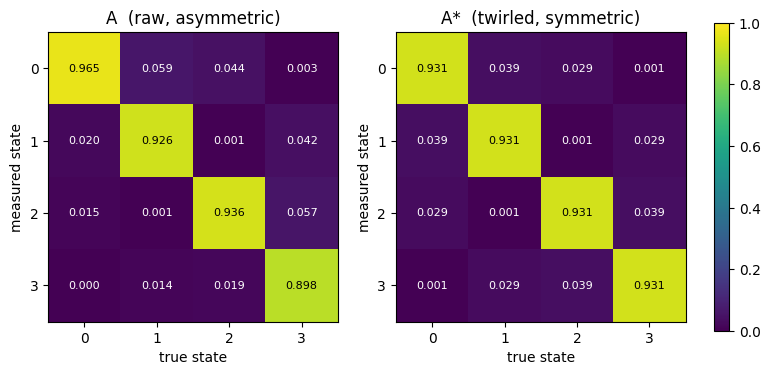

In [16]:
def twirl_confusion(spec):
    """Return (A, A*) with A* = 2^-n sum_s P_s A P_s (brute force over all flip patterns)."""
    n = spec.n_qubits
    A = spec.confusion_matrix()
    Astar = np.zeros_like(A)
    for s in range(2**n):
        P = np.zeros_like(A)
        for b in range(2**n):
            P[b ^ s, b] = 1.0
        Astar += P @ A @ P
    return A, Astar / 2**n

A, Astar = twirl_confusion(READOUT_ASYM)
print("Asymmetric readout:")
print(f"  raw asymmetry    max|A  - A^T|  = {np.max(np.abs(A - A.T)):.3e}  (clearly non-symmetric)")
print(f"  twirled          max|A* - A*^T| = {np.max(np.abs(Astar - Astar.T)):.2e}  (symmetrized)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, M, t in zip(axes, (A, Astar), ("A  (raw, asymmetric)", "A*  (twirled, symmetric)")):
    im = ax.imshow(M, vmin=0, vmax=1, cmap="viridis")
    ax.set_title(t); ax.set_xlabel("true state"); ax.set_ylabel("measured state")
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    for (r, c), v in np.ndenumerate(M):
        ax.text(c, r, f"{v:.3f}", ha="center", va="center",
                color="white" if v < 0.6 else "black", fontsize=8)
fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
plt.show()

## 4. TREX on $P(\text{target})$ — readout-only noise

With **no gate noise**, TREX should recover $P(\text{target})=1$ up to shot noise. We first sanity-
check that the observable path (`trex_success_prob`, which sums the $Z$-string corrections and re-adds
the identity offset $2^{-n}$) reproduces the direct counts-based $P(\text{target})$ on a *noiseless*
backend — the decisive endianness / observable check. Then we compare noisy vs TREX across seeds for
both readout specs. *(Validated in `smoke_trex_end2end.py`.)*

In [17]:
SEEDS_T = list(range(12))
NUM_RAND = 32
SHOTS_T = 8192
ideal_backend = AerSimulator()

print("noiseless sanity  (TREX observable path == direct P(target)):")
for s in range(4):
    direct = success_prob(ideal_backend, s)
    trex = trex_success_prob(
        benchmark_circuit_cirq(s), mitiq_measurement_executor(ideal_backend, SHOTS_T),
        target_key(s), num_randomizations=NUM_RAND, random_state=s,
    )
    print(f"  seed {s}  target={target_key(s)}  direct={direct:.4f}  TREX={trex:.4f}")

rows, results = [], {}
for spec in (READOUT_SYM, READOUT_ASYM):
    be = AerSimulator(noise_model=spec.readout_noise_model())
    noisy = np.array([success_prob(be, s) for s in SEEDS_T])
    trex = np.array([
        trex_success_prob(benchmark_circuit_cirq(s), mitiq_measurement_executor(be, SHOTS_T),
                          target_key(s), num_randomizations=NUM_RAND, random_state=s)
        for s in SEEDS_T
    ])
    results[spec.name] = (noisy, trex)
    rows.append({"readout": spec.name,
                 "noisy_bias": noisy.mean() - IDEAL, "TREX_bias": trex.mean() - IDEAL,
                 "noisy_MSE": np.mean((noisy - IDEAL) ** 2), "TREX_MSE": np.mean((trex - IDEAL) ** 2)})
summary = pd.DataFrame(rows).set_index("readout").round(5)
print("\n", summary.to_string())

noiseless sanity  (TREX observable path == direct P(target)):
  seed 0  target=01  direct=1.0000  TREX=1.0000
  seed 1  target=01  direct=1.0000  TREX=1.0000
  seed 2  target=00  direct=1.0000  TREX=1.0000
  seed 3  target=00  direct=1.0000  TREX=1.0000

              noisy_bias  TREX_bias  noisy_MSE  TREX_MSE
readout                                                
ReadoutSym     -0.05806    0.00031    0.00338   0.00000
ReadoutAsym    -0.06156    0.00427    0.00441   0.00006


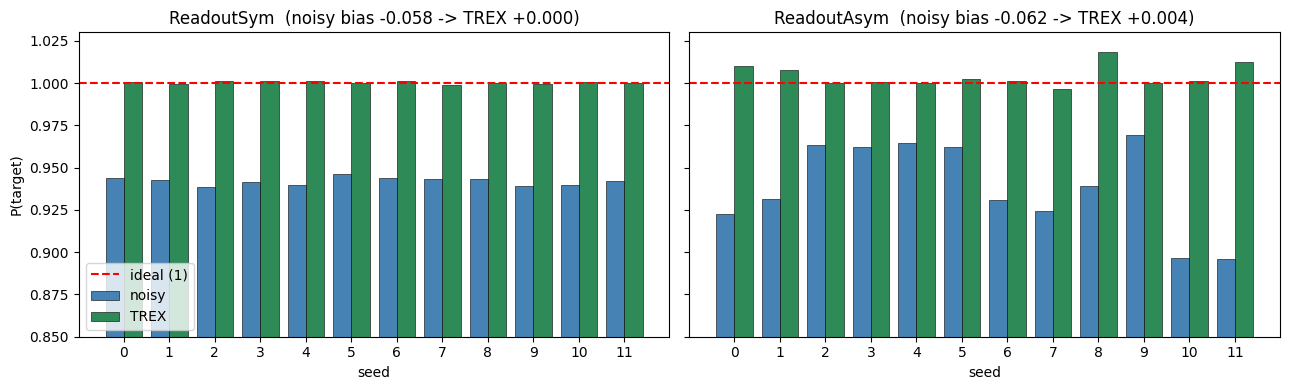

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
x = np.arange(len(SEEDS_T))
for ax, spec in zip(axes, (READOUT_SYM, READOUT_ASYM)):
    noisy, trex = results[spec.name]
    ax.bar(x - 0.2, noisy, 0.4, label="noisy", color="steelblue", edgecolor="black", linewidth=0.4)
    ax.bar(x + 0.2, trex, 0.4, label="TREX", color="seagreen", edgecolor="black", linewidth=0.4)
    ax.axhline(IDEAL, color="red", ls="--", lw=1.5, label=f"ideal ({IDEAL:.0f})")
    ax.set_title(f"{spec.name}  (noisy bias {noisy.mean()-IDEAL:+.3f} -> TREX {trex.mean()-IDEAL:+.3f})")
    ax.set_xlabel("seed"); ax.set_xticks(x); ax.set_ylim(0.85, 1.03)
axes[0].set_ylabel("P(target)"); axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

## 5. The residual $+$offset: a finite-sample ratio bias

TREX recovers $P(\text{target})$ *up to a small positive offset* on **asymmetric** readout. This is
expected, not a bug. TREX divides by an estimated calibration factor $\hat\lambda$, and van den Berg
*et al.* (Phys. Rev. A **105**, 032620, 2022, §IV) estimate $\langle\tilde Z_s\rangle$ as
$f(\mathcal{D}_1,s)/f(\mathcal{D}_0,s)$ — explicitly *"of the form $\hat x/\hat y$"*, a **ratio
estimator** whose finite-sample bias is controlled by the number of randomizations $N$ (sample
complexity $\propto 1/\lambda^2$).

Because $1/\hat\lambda$ is convex, dividing by a *noisy* $\hat\lambda$ biases the result **upward**.
The offset therefore:
- **shrinks with `num_randomizations`** $N$ — but is essentially **flat in shots** (a finite-$N$
  effect, not shot noise, and not the Aer simulator-seed artifact: the backend is seedless and the
  numerator/denominator are independent circuits);
- is **$\approx 0$ for symmetric readout**: there the per-pattern calibration factor is constant
  ($\lambda$ independent of the twirl pattern), so $\hat\lambda$ carries no pattern-variance and no
  bias. Asymmetry makes the per-pattern factor swing (e.g. $0.88\leftrightarrow0.96$) → denominator
  variance → convexity bias.

The plot overlays both specs: symmetric stays pinned at 1, asymmetric converges to 1 **from above**
as $N$ grows. Error bars are the **standard error of the mean** (std$/\sqrt{\text{seeds}}$) — the
right quantity for judging whether the offset is real. *(Fully dissected in `smoke_trex_bias.py`.)*

ReadoutSym: offset -0.0003 (N=1) -> +0.0001 (N=64)  [SEM~0.0002]
ReadoutAsym: offset +0.0106 (N=1) -> +0.0011 (N=64)  [SEM~0.0010]


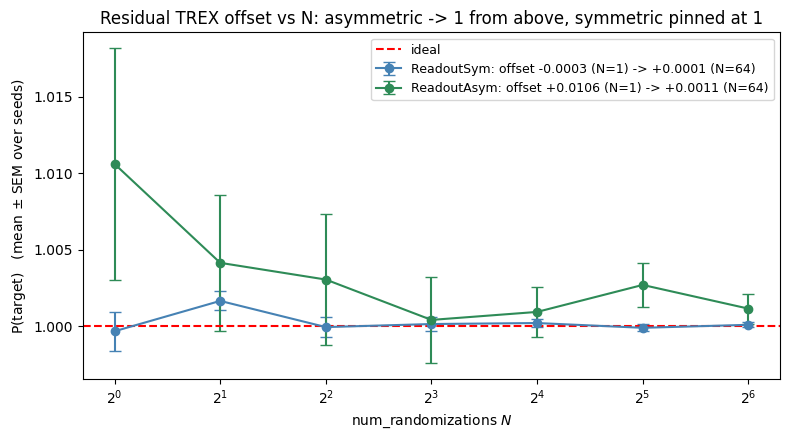

In [19]:
NR_GRID = [1, 2, 4, 8, 16, 32, 64]
SEEDS_C = list(range(24))
SHOTS_C = 4096

fig, ax = plt.subplots(figsize=(8, 4.5))
for spec, color in ((READOUT_SYM, "steelblue"), (READOUT_ASYM, "seagreen")):
    be = AerSimulator(noise_model=spec.readout_noise_model())  # seedless
    means, sems = [], []
    for nr in NR_GRID:
        vals = np.array([
            trex_success_prob(benchmark_circuit_cirq(s), mitiq_measurement_executor(be, SHOTS_C),
                              target_key(s), num_randomizations=nr, random_state=s)
            for s in SEEDS_C
        ])
        means.append(vals.mean()); sems.append(vals.std() / len(SEEDS_C) ** 0.5)
    means, sems = np.array(means), np.array(sems)
    ax.errorbar(NR_GRID, means, yerr=sems, marker="o", capsize=4, color=color,
                label=f"{spec.name}: offset {means[0]-1:+.4f} (N=1) -> {means[-1]-1:+.4f} (N={NR_GRID[-1]})")
    print(f"{spec.name}: offset {means[0]-1:+.4f} (N=1) -> {means[-1]-1:+.4f} (N={NR_GRID[-1]})  "
          f"[SEM~{sems[-1]:.4f}]")

ax.axhline(IDEAL, color="red", ls="--", lw=1.5, label="ideal")
ax.set_xscale("log", base=2); ax.set_xlabel("num_randomizations $N$")
ax.set_ylabel("P(target)   (mean $\\pm$ SEM over seeds)")
ax.set_title("Residual TREX offset vs N: asymmetric -> 1 from above, symmetric pinned at 1")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## 6. Readout on top of gate noise — TREX complements ZNE/PEC

On real hardware readout error sits *on top of* gate noise. TREX removes **only** the readout part;
the remaining gap to the ideal is gate noise, which is ZNE/PEC territory. We stack the asymmetric
readout on the depolarizing gate-noise model and check that TREX lands back at the **gate-only**
value — cleanly separating the two error budgets.

gate-only=0.5213  noisy(both)=0.5036  TREX=0.5230  (ideal=1.0)
-> TREX recovers the gate-only value (removes readout); residual +0.477 is GATE noise, for ZNE/PEC.


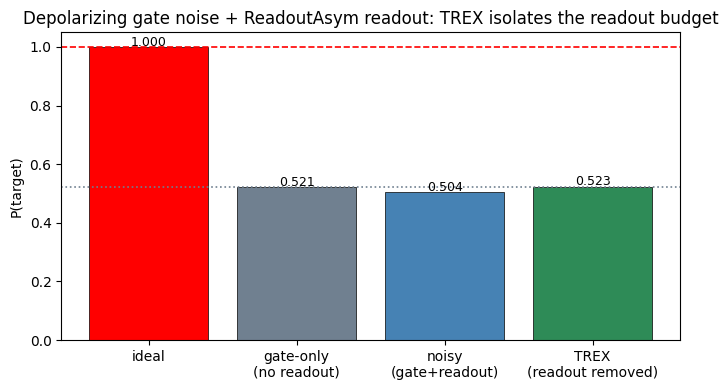

In [20]:
gate_spec = SPEC_DEPOL  # any qem gate-noise NoiseSpec; readout is attached on top
ro = READOUT_ASYM

nm_both = gate_spec.build_noise_model()
ro.add_readout_error(nm_both)                 # gate noise + readout
both_backend = AerSimulator(noise_model=nm_both)
gate_backend = AerSimulator(noise_model=gate_spec.build_noise_model())  # gate noise only

gate_only = np.array([success_prob(gate_backend, s) for s in SEEDS_T])
noisy_both = np.array([success_prob(both_backend, s) for s in SEEDS_T])
trex_both = np.array([
    trex_success_prob(benchmark_circuit_cirq(s), mitiq_measurement_executor(both_backend, SHOTS_T),
                      target_key(s), num_randomizations=NUM_RAND, random_state=s)
    for s in SEEDS_T
])

labels = ["ideal", "gate-only\n(no readout)", "noisy\n(gate+readout)", "TREX\n(readout removed)"]
vals = [IDEAL, gate_only.mean(), noisy_both.mean(), trex_both.mean()]
colors = ["red", "slategray", "steelblue", "seagreen"]
print(f"gate-only={gate_only.mean():.4f}  noisy(both)={noisy_both.mean():.4f}  "
      f"TREX={trex_both.mean():.4f}  (ideal={IDEAL})")
print(f"-> TREX recovers the gate-only value (removes readout); residual {IDEAL-trex_both.mean():+.3f} "
      f"is GATE noise, for ZNE/PEC.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(IDEAL, color="red", ls="--", lw=1.2)
ax.axhline(gate_only.mean(), color="slategray", ls=":", lw=1.2)
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylabel("P(target)"); ax.set_ylim(0, 1.05)
ax.set_title(f"{gate_spec.name} gate noise + {ro.name} readout: TREX isolates the readout budget")
plt.tight_layout(); plt.show()

### Summary

- **Readout error** is added in `qem/readout.py` (`ReadoutSpec`, Aer `add_readout_error`); its
  confusion matrix $A$ matches the simulator to shot noise (§2).
- **Twirling** turns an asymmetric $A$ into a symmetric $A^\star$ and the readout action into a pure
  eigenvalue scaling $\lambda_w=\prod_{i\in w}(1-p^0_i-p^1_i)$ (§3). Twirling the **calibration** too
  is what makes it work for asymmetric noise — the untwirled calibration would see only $p^0$.
- **TREX** (`mitiq.experimental.trex`, wrapped as `trex_success_prob`) recovers $P(\text{target})$ to
  the ideal for both symmetric and asymmetric readout (§4).
- The small residual **$+$offset on asymmetric readout** is the expected finite-$N$ **ratio-estimator
  bias** of dividing by an estimated $\hat\lambda$ (van den Berg 2022, §IV, $\hat x/\hat y$): it
  $\to 0$ as `num_randomizations` grows, is flat in shots, and is $\approx 0$ for symmetric readout
  (§5). It is *not* shot noise nor a simulator-seed artifact.
- TREX mitigates **only readout**: stacked on gate noise it returns the gate-only value, leaving the
  gate-noise budget to ZNE/PEC (§6). The two techniques are complementary.

Implementation pitfalls (for the record): TREX's `construct_circuits` needs a **LineQubit** Cirq
circuit (a Qiskit circuit converts to `NamedQubit` → `KeyError`), so we pass `benchmark_circuit_cirq`;
and mitiq's `combine_results` returns `NaN` on an **empty-support (identity)** Pauli, so
`trex_success_prob` drops it and re-adds the exact $2^{-n}$ offset.